# Simple Retrosynthesis V0.2

## Objective

Can a computer perform simple retrosynthetic transformations
based on manually defined chemical rules?

## What's new in V0.2

- Expanded from 1 reaction template to multiple templates
- Added user-input SMILES
- Added molecular and reaction visualization
- Tested and refined SMARTS matching rules

## Current limitation

These are prototype templates for testing rule-based retrosynthesis.
They do not yet guarantee chemically complete precursor generation
or experimental feasibility.

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from IPython.display import display

In [12]:
retro_templates = [
    {
        "name": "酰胺键水解切断",
        "smarts": "[C:1](=O)[N:2] >> [C:1](=O)O.[N:2]",
        "type": "亲核取代"
    },
    {
        "name": "酯键水解切断",
        "type": "亲核取代",
        "smarts": "[#6:1](=O)[O:2][#6:3] >> [#6:1](=O)O.[O:2][#6:3]"
    },
    {
        "name": "酰卤水解切断",
        "type": "亲核取代",
        "smarts": "[C:1](=O)[X:2] >> [C:1](=O)O.[X:2]"
    },
    {
        "name": "酸酐水解切断",
        "type": "亲核取代",
        "smarts": "[C:1](=O)O[C:2](=O) >> [C:1](=O)O.[C:2](=O)O"
    },
    {
        "name": "腈水解切断",
        "type": "官能团转化",
        "smarts": "[C:1]#N >> [C:1](=O)O"
    },
    {
        "name": "卤代烃水解切断",
        "type": "亲核取代",
        "smarts": "[CX4:1][X:2] >> [CX4:1]O.[X:2]"
    },
    {
        "name": "脂肪醇氯代",
        "type": "亲核取代",
        "smarts": "[CX4:1][O:2] >> [CX4:1]Cl.[O:2]"
    },
    {
        "name": "脂肪醇溴代",
        "type": "亲核取代",
        "smarts": "[CX4:1][O:2] >> [CX4:1]Br.[O:2]"
    }
]


请输入目标分子的SMILES： O=C(C)Oc1ccccc1C(=O)O


✅ 目标分子： O=C(C)Oc1ccccc1C(=O)O


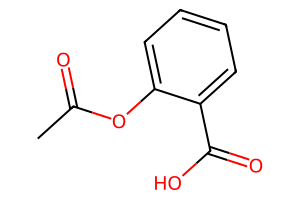

In [13]:
target_smiles = input("请输入目标分子的SMILES：")
try:
    target_mol = Chem.MolFromSmiles(target_smiles)
    if target_mol is None:
        print("❌ 无效的SMILES，请检查输入")
    else:
        print("✅ 目标分子：", target_smiles)
        display(Draw.MolToImage(target_mol, size=(300, 200)))
except:
    print("❌ 解析出错")

未匹配：酰胺键水解切断
匹配成功：酯键水解切断
  切断结果1: CC(=O)O + O=C(O)c1ccccc1O


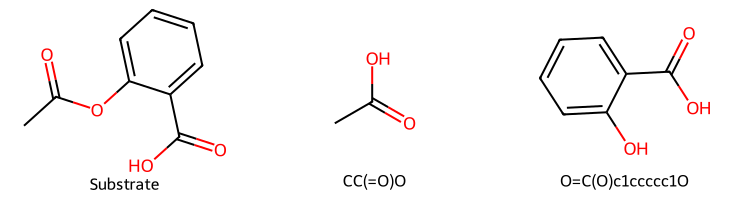

未匹配：酰卤水解切断
未匹配：酸酐水解切断
未匹配：腈水解切断
未匹配：卤代烃水解切断
未匹配：脂肪醇氯代
未匹配：脂肪醇溴代


In [14]:
for template in retro_templates:
    rxn = AllChem.ReactionFromSmarts(template["smarts"])
    products_list = rxn.RunReactants([target_mol])

    if products_list:
        print(f"匹配成功：{template['name']}")
        for i, products in enumerate(products_list, 1):
            fragments = [Chem.MolToSmiles(mol) for mol in products]
            print(f"  切断结果{i}: {' + '.join(fragments)}")
            reaction_mols = [target_mol] + list(products)
            display(Draw.MolsToGridImage(
            reaction_mols,
            molsPerRow=3,
            subImgSize=(250, 200),
            legends=["Substrate"] + fragments
            ))

    else:
        print(f"未匹配：{template['name']}")